<a href="https://colab.research.google.com/github/asdmhdibcu/fraud-detection-system/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install kaggle -q


In [19]:
import os

# Replace the text inside the quotes with your actual Kaggle info
os.environ['KAGGLE_USERNAME'] = 'asadmehdi096'
os.environ['KAGGLE_KEY'] = 'KGAT_ecfed8945a03e7a67d7fae6a380b9970'

print("Credentials set!")


Credentials set!


In [2]:
import kagglehub

# This creates the variable 'path'
path = kagglehub.dataset_download("lnasiri007/ieeecis-fraud-detection")



Using Colab cache for faster access to the 'ieeecis-fraud-detection' dataset.


In [3]:
import pandas as pd
import os

# We use os.path.join to combine the folder 'path' with the filenames
train_trans = pd.read_csv(os.path.join(path, "train_transaction.csv"))
train_id = pd.read_csv(os.path.join(path, "train_identity.csv"))

# Merge and check
df = pd.merge(train_trans, train_id, on='TransactionID', how='left')
print("Successfully loaded and merged!")
print(f"Dataset Path: {path}")
df.head()


Successfully loaded and merged!
Dataset Path: /kaggle/input/ieeecis-fraud-detection


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [4]:
# Show percentage of missing values for the first 20 columns
missing_pct = df.isnull().mean() * 100
print("Missing Data Percentage (Top 20 columns):")
print(missing_pct.head(20))


Missing Data Percentage (Top 20 columns):
TransactionID      0.000000
isFraud            0.000000
TransactionDT      0.000000
TransactionAmt     0.000000
ProductCD          0.000000
card1              0.000000
card2              1.512683
card3              0.265012
card4              0.267044
card5              0.721204
card6              0.266028
addr1             11.126427
addr2             11.126427
dist1             59.652352
dist2             93.628374
P_emaildomain     15.994852
R_emaildomain     76.751617
C1                 0.000000
C2                 0.000000
C3                 0.000000
dtype: float64


In [5]:

print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.2f}%")


Shape: (590540, 434)
Fraud rate: 3.50%


In [6]:
fraud = df['isFraud'].value_counts()
print(f"Legitimate: {fraud[0]:,}")
print(f"Fraud:      {fraud[1]:,}")
print()
print(f"If your model predicted ZERO fraud on every transaction,")
print(f"it would be {fraud[0]/len(df)*100:.1f}% accurate.")
print(f"That's why accuracy is useless here.")


Legitimate: 569,877
Fraud:      20,663

If your model predicted ZERO fraud on every transaction,
it would be 96.5% accurate.
That's why accuracy is useless here.


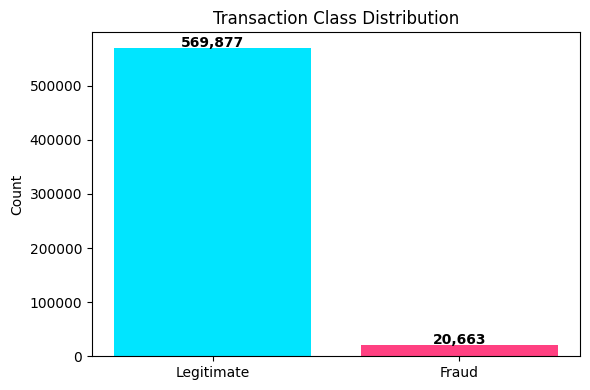

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legitimate', 'Fraud'],
       [fraud[0], fraud[1]],
       color=['#00E5FF', '#FF4081'])
ax.set_title('Transaction Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate([fraud[0], fraud[1]]):
    ax.text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

print(f"Columns WITH missing values: {len(null_pct)}")
print(f"Columns with MORE THAN 50% missing: {(null_pct > 50).sum()}")
print()
print("Top 10 worst columns:")
print(null_pct.head(10).round(1).to_string())


Columns WITH missing values: 414
Columns with MORE THAN 50% missing: 214

Top 10 worst columns:
id_24    99.2
id_25    99.1
id_07    99.1
id_08    99.1
id_21    99.1
id_26    99.1
id_27    99.1
id_23    99.1
id_22    99.1
dist2    93.6


In [9]:
import numpy as np

fraud_amt = df[df['isFraud']==1]['TransactionAmt']
legit_amt = df[df['isFraud']==0]['TransactionAmt']

print("FRAUD transactions:")
print(f"  Median: ${fraud_amt.median():.2f}")
print(f"  Mean:   ${fraud_amt.mean():.2f}")
print(f"  Max:    ${fraud_amt.max():.2f}")
print()
print("LEGITIMATE transactions:")
print(f"  Median: ${legit_amt.median():.2f}")
print(f"  Mean:   ${legit_amt.mean():.2f}")
print(f"  Max:    ${legit_amt.max():.2f}")


FRAUD transactions:
  Median: $75.00
  Mean:   $149.24
  Max:    $5191.00

LEGITIMATE transactions:
  Median: $68.50
  Mean:   $134.51
  Max:    $31937.39


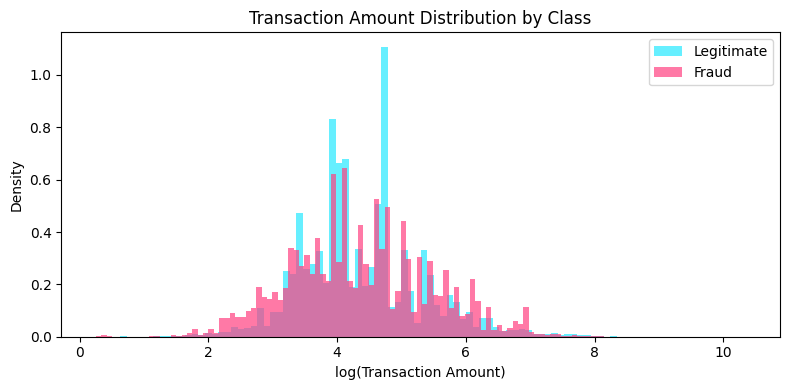

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(legit_amt), bins=100, alpha=0.6,
        color='#00E5FF', label='Legitimate', density=True)
ax.hist(np.log1p(fraud_amt), bins=100, alpha=0.7,
        color='#FF4081', label='Fraud', density=True)
ax.set_xlabel('log(Transaction Amount)')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount Distribution by Class')
ax.legend()
plt.tight_layout()
plt.show()


In [11]:
print("=" * 45)
print("EDA SUMMARY — Day 1")
print("=" * 45)
print(f"Total transactions:        {len(df):,}")
print(f"Total features:            {df.shape[1]}")
print(f"Fraud rate:                {df['isFraud'].mean()*100:.2f}%")
print(f"Columns with nulls:        {(df.isnull().sum()>0).sum()}")
print(f"Columns >50% null:         {(df.isnull().mean()>0.5).sum()}")
print()
print("DECISIONS MADE TODAY:")
print("  1. Metric = AUC-ROC, NOT accuracy")
print("  2. Missing values → fill with -999")
print("  3. TransactionAmt → log transform")
print("  4. Class imbalance → handle in model training")
print()
print("NEXT SESSION: Feature Engineering")


EDA SUMMARY — Day 1
Total transactions:        590,540
Total features:            434
Fraud rate:                3.50%
Columns with nulls:        414
Columns >50% null:         214

DECISIONS MADE TODAY:
  1. Metric = AUC-ROC, NOT accuracy
  2. Missing values → fill with -999
  3. TransactionAmt → log transform
  4. Class imbalance → handle in model training

NEXT SESSION: Feature Engineering
